In [1]:
import datetime
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline
import os
import seaborn as sns
import statsmodels.api as sm
import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA 

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
os.chdir('C:\\Users\\loren\\OneDrive - Università degli Studi di Milano\\Lezioni uni\\Tesi\\Dataset Energia\\')
path = 'Italy'

In [3]:
df2016 = pd.read_csv(os.path.join(path, f"ITA2016.csv"), parse_dates = ['MTU'])
df2017 = pd.read_csv(os.path.join(path, f"ITA2017.csv"), parse_dates = ['MTU'])
df2018 = pd.read_csv(os.path.join(path, f"ITA2018.csv"), parse_dates = ['MTU'])
df2019 = pd.read_csv(os.path.join(path, f"ITA2019.csv"), parse_dates = ['MTU'])
df2020 = pd.read_csv(os.path.join(path, f"ITA2020.csv"), parse_dates = ['MTU'])
df2021 = pd.read_csv(os.path.join(path, f"ITA2021.csv"), parse_dates = ['MTU'])

In [4]:
def retrieve_data(path):
    # creo il vettore degli anni e il df vuoto dove appendere i singoli df
    years = [2016, 2017, 2018, 2019, 2020, 2021]
    tot = pd.DataFrame()
    
    # carico i dati dei diversi anni
    for year in years:
        df = pd.read_csv(os.path.join(path, f"ITA{year}.csv"), parse_dates = ['MTU'])
        #df = df.reset_index()
        
        # aggiusto il formato della data in YYYY-MM-DD HH:mm
        for i, row in df.iterrows():
            df["MTU"][i] = df['MTU'][i][:16]
        
        df['Time'] = pd.to_datetime(df['MTU'], utc=True, infer_datetime_format=True)
        df.Time = df.Time.dt.strftime('%Y-%m-%d')
        df = df.set_index(pd.DatetimeIndex(df['Time']))

        # elimino colonne con solo NA
        df = df.drop(columns=['MTU','Area','Fossil Brown coal/Lignite  - Actual Aggregated [MW]','Fossil Oil shale  - Actual Aggregated [MW]',
                     'Fossil Peat  - Actual Aggregated [MW]', 'Marine  - Actual Aggregated [MW]', 'Nuclear  - Actual Aggregated [MW]',
                     'Wind Offshore  - Actual Aggregated [MW]', 'Other renewable  - Actual Aggregated [MW]'])
        
        # appendo i vari df a quello vuoto principale
        tot = pd.concat([tot, df], ignore_index=True)
    
    # imposto la data come indice
    tot = tot.set_index(pd.DatetimeIndex(tot['Time']))
    return tot

In [5]:
data = retrieve_data(path)

C:\Users\loren\AppData\Local\Temp\ipykernel_5624\2564700696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MTU"][i] = df['MTU'][i][:16]
C:\Users\loren\AppData\Local\Temp\ipykernel_5624\2564700696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MTU"][i] = df['MTU'][i][:16]
C:\Users\loren\AppData\Local\Temp\ipykernel_5624\2564700696.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MTU"][i] = df['MTU'][i][:16]
C

In [6]:
print('There are {} missing values or NaNs in df_final.'.format(data.isnull().values.sum()))

There are 17584 missing values or NaNs in df_final.


In [7]:
data.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [8]:
data.describe()

,Biomass - Actual Aggregated [MW],Fossil Coal-derived gas - Actual Aggregated [MW],Fossil Gas - Actual Aggregated [MW],Fossil Hard coal - Actual Aggregated [MW],Fossil Oil - Actual Aggregated [MW],Geothermal - Actual Aggregated [MW],Hydro Pumped Storage - Actual Aggregated [MW],Hydro Pumped Storage - Actual Consumption [MW],Hydro Run-of-river and poundage - Actual Aggregated [MW],Hydro Water Reservoir - Actual Aggregated [MW],Other - Actual Aggregated [MW],Solar - Actual Aggregated [MW],Waste - Actual Aggregated [MW],Wind Onshore - Actual Aggregated [MW]
count,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000,52614.000000
mean,491.304482,411.358526,10398.377352,1876.884736,135.662457,650.406812,380.245800,285.435816,3818.574676,789.196203,5584.579665,2185.143498,37.795957,2114.967784
std,165.546821,241.377903,4702.358879,967.511420,116.660972,22.489450,518.017544,422.781559,1577.662605,489.626447,3856.001692,3040.677333,8.574162,1525.440236
min,167.000000,0.000000,1590.000000,204.000000,0.000000,485.000000,0.000000,1.000000,774.000000,14.000000,623.000000,0.000000,5.000000,20.000000
25%,334.000000,232.000000,6674.000000,1170.000000,39.000000,637.000000,5.000000,25.000000,2540.000000,402.000000,2222.000000,0.000000,32.000000,858.000000
50%,481.000000,280.000000,9641.000000,1582.000000,93.000000,653.000000,167.000000,112.750000,3691.000000,708.000000,4079.500000,60.000000,39.000000,1753.000000
75%,652.000000,592.000000,13422.750000,2452.000000,209.000000,667.000000,542.000000,349.000000,4975.000000,1115.000000,8445.750000,4178.000000,44.000000,3084.000000
max,845.000000,1135.000000,27688.000000,6198.000000,783.000000,707.000000,4526.000000,3974.000000,8534.000000,2872.000000,19489.000000,11812.000000,62.000000,7611.000000


Appunto: TERNA informs the platform users that from 27th June 2017 the category “Other” has been redistributed to the correct Types.
TERNA informs the platform users that actual data is reported on a provisional basis. Provisional data can be subject to adjustments and recalculations.
Cacchio vuol dire? Mannaggiatterna

In [9]:
def daily_data_and_aggregator(df):

    # seleziono tutte le colonne delle fonti energetiche
    columns = df.columns[ : data.shape[1]-1]

    # aggrego giornalmente i dati
    daily_df = pd.DataFrame(df[columns].groupby([pd.Grouper(level='Time', freq='D')]).sum())

    # creo l'aggregato totale
    daily_df['total_aggregated'] = daily_df[columns].sum(axis=1)

    return daily_df

In [10]:
daily_data = daily_data_and_aggregator(data)

In [11]:
daily_data.total_aggregated.describe()

count      2192.000000
mean     699918.227646
std      103382.026351
min      459101.000000
25%      614134.500000
50%      708275.986111
75%      776133.742424
max      978987.375000
Name: total_aggregated, dtype: float64

In [12]:
# creo due dunzioni: una per i weekend (quando sabato/domenica è 1, altrimenti 0) e l'altra per le vacanze (1/1, 25/4, 1/5, 2/6, 15/8, 25/12)
def weekend_generation(df):
    # Generate 'weekend' feature
    for i in range(len(df)):
        position = df.index[i]
        hour = position.hour
        weekend = position.weekday()
        month = position.month
        df.loc[position, 'weekend'] = weekend

    for i in range(len(df)):
        position = df.index[i]
        weekend = position.weekday()
        if (weekend >= 5):
            df.loc[position, 'weekend'] = 1
        else:
            df.loc[position, 'weekend'] = 0
    return df

In [13]:
daily_data2 = weekend_generation(daily_data)

<AxesSubplot: xlabel='Time'>

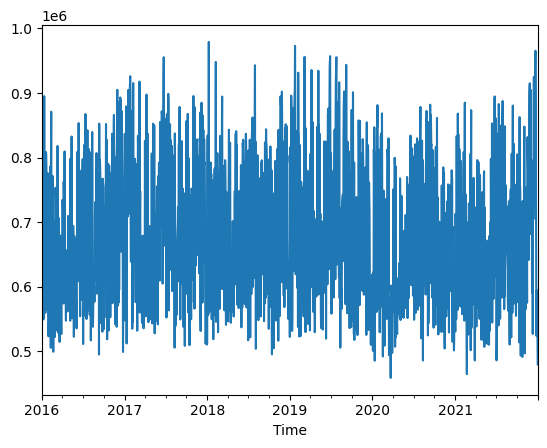

In [14]:
daily_data2['total_aggregated'].plot()

# ARIMA: AR(1)

In [15]:

# Facciamo test di stazionarietà classico col DF
df_stationarityTest = adfuller(daily_data['total_aggregated'], autolag='AIC')

# Check del p-value: è decisamente sotto 0.05, quindi la serie è stazionaria, no unit root
print("P-value: ", df_stationarityTest[1])

P-value:  6.441636980544729e-10


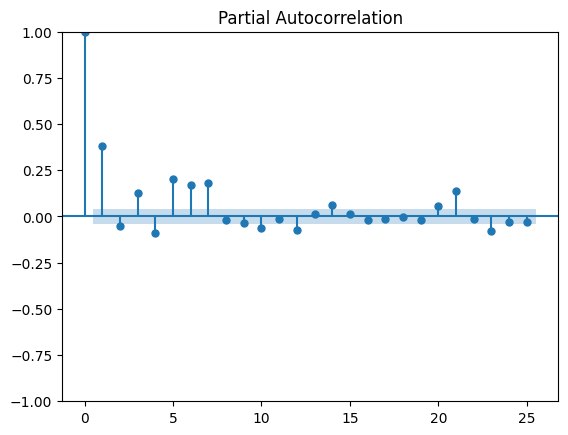

In [16]:
# Ora trovare l'ordine del nostro AR
# Plotto il grafico delle autocorrelazioni per determinare
# quando decade la dipendenza col passato
from statsmodels.graphics.tsaplots import plot_pacf
pacf = plot_pacf(daily_data['total_aggregated'], lags=25, method='ywm')

# dal grafico si nota che la dipendenza col passato decade dopo il primo lag, quindi useremo un AR(1)

In [17]:
# splitto il dataframe in train e test. dovendo usare gli ultimi due anni come test set, 
# utilizzo per quest'ultimo le ultime 730 osservazioni (365*2)
series = daily_data['total_aggregated']
X = series.values

In [18]:
train, test = X[0:len(X)-730], X[len(X)-730:]

In [19]:
model = ARIMA(series, order=(1,0,0))
model_fit = model.fit()
# summary of fit model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       total_aggregated   No. Observations:                 2192
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -28245.412
Date:                Thu, 23 Feb 2023   AIC                          56496.824
Time:                        09:10:59   BIC                          56513.901
Sample:                    01-01-2016   HQIC                         56503.065
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.999e+05   3308.295    211.565      0.000    6.93e+05    7.06e+05
ar.L1          0.3835      0.018     21.054      0.000       0.348       0.419
sigma2      9.103e+09      0.001   7.99e+12      0.0

predicted=641045.513893, expected=619526.400000
predicted=676336.504330, expected=501058.000000
predicted=634631.404697, expected=622421.000000
predicted=677121.283955, expected=557044.666667
predicted=654029.530998, expected=604723.500000
predicted=670687.648697, expected=813048.633929
predicted=743929.477486, expected=758877.000000
predicted=724949.826137, expected=846902.333333
predicted=755965.847559, expected=702444.500000
predicted=705202.889182, expected=485780.000000
predicted=629060.849056, expected=784734.000000
predicted=733847.728594, expected=779109.000000
predicted=731934.579567, expected=808540.500000
predicted=742287.128393, expected=808441.000000
predicted=742341.402118, expected=792847.000000
predicted=736953.365395, expected=786202.000000
predicted=734683.454140, expected=640239.500000
predicted=683544.003878, expected=561098.000000
predicted=655712.010155, expected=800518.000000
predicted=739524.100641, expected=846101.000000
predicted=755586.020538, expected=848347

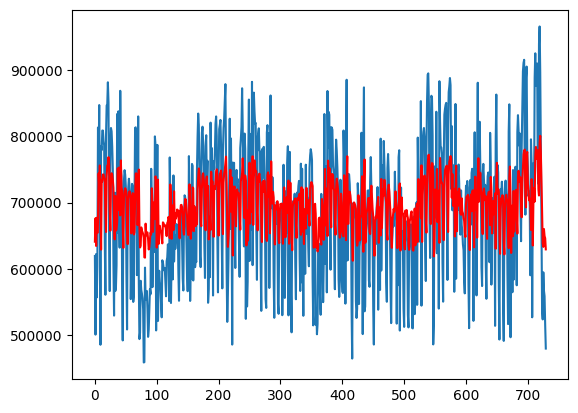

In [20]:
# train autoregression
history = [x for x in train]
predictions = list()
for t in range(len(test)):
    model = ARIMA(history, order=(1,0,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

In [21]:
scaler = MinMaxScaler(feature_range = (-1,1))

norm_series = pd.DataFrame(series)
norm_series = scaler.fit_transform(norm_series)

In [22]:
train_norm, test_norm = norm_series[0:len(norm_series)-730], norm_series[len(norm_series)-730:]
model = ARIMA(norm_series, order=(1,0,0))
model_fit = model.fit()
# summary of fit model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2192
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -915.075
Date:                Thu, 23 Feb 2023   AIC                           1836.150
Time:                        09:12:35   BIC                           1853.228
Sample:                             0   HQIC                          1842.392
                               - 2192                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0741      0.013     -5.807      0.000      -0.099      -0.049
ar.L1          0.3835      0.019     20.047      0.000       0.346       0.421
sigma2         0.1349      0.005     26.932      0.0

predicted=-0.300442, expected=-0.382844
predicted=-0.164583, expected=-0.838592
predicted=-0.325133, expected=-0.371709
predicted=-0.161562, expected=-0.623211
predicted=-0.250457, expected=-0.439791
predicted=-0.186329, expected=0.361635
predicted=0.095624, expected=0.153237
predicted=0.022559, expected=0.491870
predicted=0.141959, expected=-0.063859
predicted=-0.053458, expected=-0.897366
predicted=-0.346575, expected=0.252708
predicted=0.056815, expected=0.231069
predicted=0.049450, expected=0.344292
predicted=0.089303, expected=0.343909
predicted=0.089511, expected=0.283919
predicted=0.068769, expected=0.258356
predicted=0.060030, expected=-0.303161
predicted=-0.136835, expected=-0.607618
predicted=-0.243977, expected=0.313429
predicted=0.078666, expected=0.488787
predicted=0.140498, expected=0.497427
predicted=0.144210, expected=0.623737
predicted=0.189565, expected=0.508766
predicted=0.149861, expected=-0.252148
predicted=-0.118499, expected=-0.586169
predicted=-0.236490, expecte

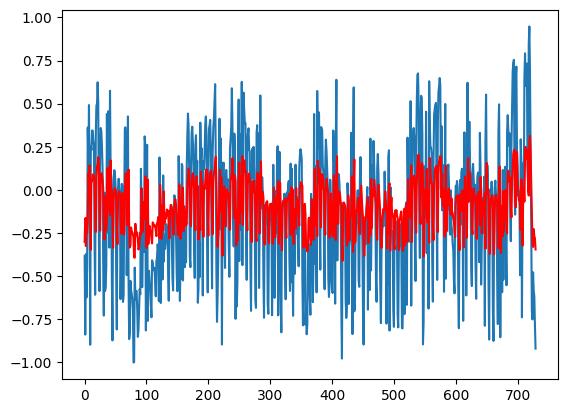

In [23]:
# train autoregression
history = [x for x in train_norm]
predictions = list()
for t in range(len(test_norm)):
    model = ARIMA(history, order=(1,0,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test_norm[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))
rmse = sqrt(mean_squared_error(test_norm, predictions))

print('Test RMSE: %.3f' % rmse)
# plot
pyplot.plot(test_norm)
pyplot.plot(predictions, color='red')
pyplot.show()

In [24]:
print(np.mean(rmse))

0.36382596527520256


# LSTM

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

In [83]:
def create_sliding_window(data, sequence_length, stride=1):
    X_list, y_list = [], []
    for i in range(len(data)):
      if (i + sequence_length) < len(data):
        X_list.append(data.iloc[i:i+sequence_length:stride, :].values)
        y_list.append(data.iloc[i+sequence_length, -1])
    return np.array(X_list), np.array(y_list)

train_split = 0.7
n_train = 1460
n_test = 732

features = ['total_aggregated']
feature_array = daily_data2[features].values

# Fit Scaler only on Training features
feature_scaler = MinMaxScaler()
feature_scaler.fit(feature_array[:n_train])
# Fit Scaler only on Training target values
target_scaler = MinMaxScaler(feature_range = (-1,1))
target_scaler.fit(feature_array[:n_train, -1].reshape(-1, 1))

# Transfom on both Training and Test data
scaled_array = pd.DataFrame(feature_scaler.transform(feature_array),
                            columns=features)

sequence_length = 1
X, y = create_sliding_window(scaled_array, 
                             sequence_length)

X_train = X[:n_train]
y_train = y[:n_train]

X_test = X[n_train:]
y_test = y[n_train:]

In [84]:
class BaseLSTM(nn.Module):

    def __init__(self, n_features, output_length, batch_size):

        super(BaseLSTM, self).__init__()

        self.batch_size = batch_size # user-defined

        self.hidden_size_1 = 256 # number of encoder cells (from paper)
        self.hidden_size_2 = 32 # number of decoder cells (from paper)
        self.stacked_layers = 2 # number of (stacked) LSTM layers for each stage
        self.dropout_probability = 0.5 # arbitrary value (the paper suggests that performance is generally stable across all ranges)

        self.lstm1 = nn.LSTM(n_features, 
                             self.hidden_size_1, 
                             num_layers=self.stacked_layers,
                             batch_first=True)
        self.lstm2 = nn.LSTM(self.hidden_size_1,
                             self.hidden_size_2,
                             num_layers=self.stacked_layers,
                             batch_first=True)
        
        self.fc = nn.Linear(self.hidden_size_2, output_length)
        self.loss_fn = nn.MSELoss()
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        hidden = self.init_hidden1(batch_size)
        output, _ = self.lstm1(x, hidden)
        state = self.init_hidden2(batch_size)
        output, state = self.lstm2(output, state)
        output = F.dropout(output, p=self.dropout_probability, training=True)
        output = output[:, -1, :] # take the last decoder cell's outputs
        y_pred = self.fc(output)
        return y_pred
        
    def init_hidden1(self, batch_size):
        hidden_state = Variable(torch.zeros(self.stacked_layers, batch_size, self.hidden_size_1))
        cell_state = Variable(torch.zeros(self.stacked_layers, batch_size, self.hidden_size_1))
        return hidden_state, cell_state
    
    def init_hidden2(self, batch_size):
        hidden_state = Variable(torch.zeros(self.stacked_layers, batch_size, self.hidden_size_2))
        cell_state = Variable(torch.zeros(self.stacked_layers, batch_size, self.hidden_size_2))
        return hidden_state, cell_state
    
    def loss(self, pred, truth):
        return self.loss_fn(pred, truth)

    def predict(self, X):
        return self(torch.tensor(X, dtype=torch.float32)).view(-1).detach().numpy()

In [85]:
n_features = scaled_array.shape[-1]
sequence_length = 1
output_length = 1

batch_size = 256
n_epochs = 100
learning_rate = 0.01

base_lstm = BaseLSTM(n_features=n_features,
                             output_length=output_length,
                             batch_size = batch_size)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(base_lstm.parameters(), lr=learning_rate)

In [86]:
base_lstm.train()

for e in range(1, n_epochs+1):
    for b in range(0, len(X_train), batch_size):
        features = X_train[b:b+batch_size,:,:]
        target = y_train[b:b+batch_size]    

        X_batch = torch.tensor(features,dtype=torch.float32)    
        y_batch = torch.tensor(target,dtype=torch.float32)

        output = base_lstm(X_batch)
        loss = criterion(output.view(-1), y_batch)  

        loss.backward()
        optimizer.step()        
        optimizer.zero_grad() 

    if e % 1 == 0:
      print('epoch', e, 'loss: ', loss.item())

epoch 1 loss:  0.08778537809848785
epoch 2 loss:  0.05889242887496948
epoch 3 loss:  0.05068514496088028
epoch 4 loss:  0.04795880243182182
epoch 5 loss:  0.04877692461013794
epoch 6 loss:  0.048974134027957916
epoch 7 loss:  0.048413366079330444
epoch 8 loss:  0.04461197182536125
epoch 9 loss:  0.04761803522706032
epoch 10 loss:  0.04631096497178078
epoch 11 loss:  0.04589911177754402
epoch 12 loss:  0.041649363934993744
epoch 13 loss:  0.0402388833463192
epoch 14 loss:  0.0401269905269146
epoch 15 loss:  0.040792278945446014
epoch 16 loss:  0.04084232822060585
epoch 17 loss:  0.04152615740895271
epoch 18 loss:  0.03930908814072609
epoch 19 loss:  0.04130200669169426
epoch 20 loss:  0.03877529129385948
epoch 21 loss:  0.03923932835459709
epoch 22 loss:  0.04073002561926842
epoch 23 loss:  0.040246639400720596
epoch 24 loss:  0.04053642973303795
epoch 25 loss:  0.039606016129255295
epoch 26 loss:  0.03854841738939285
epoch 27 loss:  0.03966118395328522
epoch 28 loss:  0.040101449936628

In [87]:
norm_df = pd.DataFrame(norm_series, columns=(['total_scaled']))
norm_df['date'] = daily_data2.index

In [88]:
offset = sequence_length

def inverse_transform(y):
  return target_scaler.inverse_transform(y.reshape(-1, 1))
 
daily_data2['date'] = daily_data2.index

training_df = pd.DataFrame()
training_df['date'] = norm_df['date'].iloc[offset:n_train + offset:1] 
training_predictions = base_lstm.predict(X_train)
training_df['load'] = training_predictions #inverse_transform(training_predictions)
training_df['source'] = 'Training Prediction'

training_truth_df = pd.DataFrame()
training_truth_df['date'] = training_df['date']
training_truth_df['load'] = norm_df['total_scaled'].iloc[offset:n_train + offset:1] 
training_truth_df['source'] = 'True Values'

testing_df = pd.DataFrame()
testing_df['date'] = norm_df['date'].iloc[n_train + offset::1] 
testing_predictions = base_lstm.predict(X_test)
testing_df['load'] = testing_predictions  #inverse_transform(training_predictions)
testing_df['source'] = 'Test Prediction'

testing_truth_df = pd.DataFrame()
testing_truth_df['date'] = testing_df['date']
testing_truth_df['load'] = norm_df['total_scaled'].iloc[n_train + offset::1] 
testing_truth_df['source'] = 'True Values'

evaluation = pd.concat([training_df, 
                        testing_df,
                        training_truth_df,
                        testing_truth_df
                        ], axis=0)


                        

In [91]:
training_df

,date,load,source
1,2016-01-02,0.426498,Training Prediction
2,2016-01-03,0.443028,Training Prediction
3,2016-01-04,0.435058,Training Prediction
4,2016-01-05,0.379211,Training Prediction
5,2016-01-06,0.408607,Training Prediction
...,...,...,...
1456,2019-12-27,0.421695,Training Prediction
1457,2019-12-28,0.395202,Training Prediction
1458,2019-12-29,0.388180,Training Prediction
1459,2019-12-30,0.402560,Training Prediction


In [92]:
train_errors =pd.DataFrame()
test_errors = pd.DataFrame()
train_errors['train_true'] = training_truth_df['load']
train_errors['train_pred'] = training_df['load']
test_errors['test_true'] = testing_truth_df['load']
test_errors['test_pred'] = testing_df['load']

In [93]:
test_errors

,test_true,test_pred
1461,-0.772246,0.413183
1462,-0.382844,0.421706
1463,-0.838592,0.396734
1464,-0.371709,0.424166
1465,-0.623211,0.360140
...,...,...
2187,-0.477343,0.422965
2188,-0.583667,0.383857
2189,-0.615416,0.385922
2190,-0.783116,0.390495


In [61]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [75]:
evaluation

,date,load,source
1,2016-01-02,0.442542,Training Prediction
2,2016-01-03,0.446165,Training Prediction
3,2016-01-04,0.436607,Training Prediction
4,2016-01-05,0.372186,Training Prediction
5,2016-01-06,0.398417,Training Prediction
...,...,...,...
2187,2021-12-27,-0.477343,True Values
2188,2021-12-28,-0.583667,True Values
2189,2021-12-29,-0.615416,True Values
2190,2021-12-30,-0.783116,True Values


In [94]:
import plotly.express as px
fig = px.line(evaluation.loc[evaluation['date'].between('2020-01-01', '2021-12-31')],
                 x="date",
                 y="load",
                 color='source',
                 title="Energy Consumption in Wh vs Time")
fig.show()